# K-Nearest Neighbors (KNN)

- KNN: classifies a new point based on the majority class among its K nearest neighbors (by distance)
- Lazy learner — no training phase, just stores data and computes distances at prediction time
- Dataset: heart.csv (predicting target — presence of heart disease)[https://www.kaggle.com/code/mohamadjavadrahmani/heart/input](https://)

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("/content/heart.csv")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

X = df.drop("target", axis=1)
Y = df["target"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print("Train size:", X_train.shape[0])
print("Test size :", X_test.shape[0])

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, Y_train)

Y_pred = model.predict(X_test)
print(pd.DataFrame({"Actual": Y_test, "Predicted": Y_pred}))

cm = confusion_matrix(Y_test, Y_pred)
acc = accuracy_score(Y_test, Y_pred)
print("Confusion Matrix:\n", cm)
print("Accuracy:", round(acc, 4))

Train size: 242
Test size : 61
     Actual  Predicted
179       0          0
228       0          0
111       1          1
246       0          0
60        1          1
..      ...        ...
249       0          0
104       1          1
300       0          0
193       0          0
184       0          0

[61 rows x 2 columns]
Confusion Matrix:
 [[27  2]
 [ 4 28]]
Accuracy: 0.9016


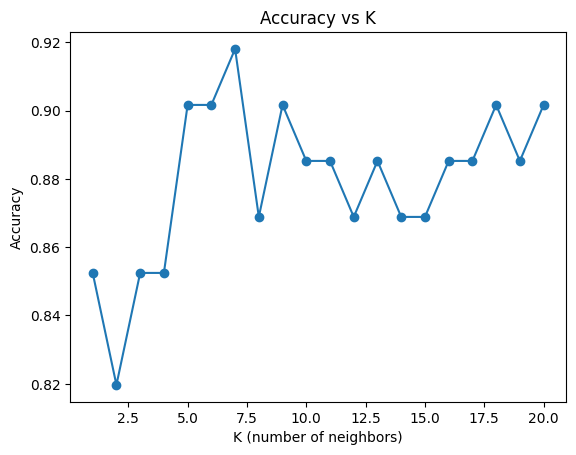

Best K: 7 with Accuracy: 0.918


In [6]:
accuracies = []
k_range = range(1, 21)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, Y_train)
    pred = knn.predict(X_test)
    accuracies.append(accuracy_score(Y_test, pred))

plt.plot(k_range, accuracies, marker="o")
plt.xlabel("K (number of neighbors)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K")
plt.show()

best_k = k_range[accuracies.index(max(accuracies))]
print("Best K:", best_k, "with Accuracy:", round(max(accuracies), 4))